In [50]:
print("\n" + "=" * 50)
print("GOLD PRICE ANALYSIS SUMMARY")
print("=" * 50)

start = data["Close"].iloc[0]
end = data["Close"].iloc[-1]
change = ((end - start) / start) * 100

print(f"\nPeriod: {data.index.min().date()} to {data.index.max().date()}")
print(f"\nPrice Overview:")
print(f"  Starting: ${start:.2f}")
print(f"  Ending: ${end:.2f}")
print(f"  Change: {change:+.2f}%")
print(f"  High: ${data['Close'].max():.2f}")
print(f"  Low: ${data['Close'].min():.2f}")
print(f"  Average: ${data['Close'].mean():.2f}")

# Calculate daily returns
daily_return = data["Close"].pct_change() * 100
pos = (daily_return > 0).sum()
total = len(data) - 1
print(f"\nTrading Days:")
print(f"  Up days: {pos} ({(pos/total)*100:.1f}%)")
print(f"  Down days: {total-pos} ({((total-pos)/total)*100:.1f}%)")

print("\n" + "=" * 50)


GOLD PRICE ANALYSIS SUMMARY

Period: 2011-12-15 to 2018-12-31

Price Overview:
  Starting: $152.33
  Ending: $121.25
  Change: -20.40%
  High: $173.61
  Low: $100.50
  Average: $127.32

Trading Days:
  Up days: 858 (50.0%)
  Down days: 859 (50.0%)



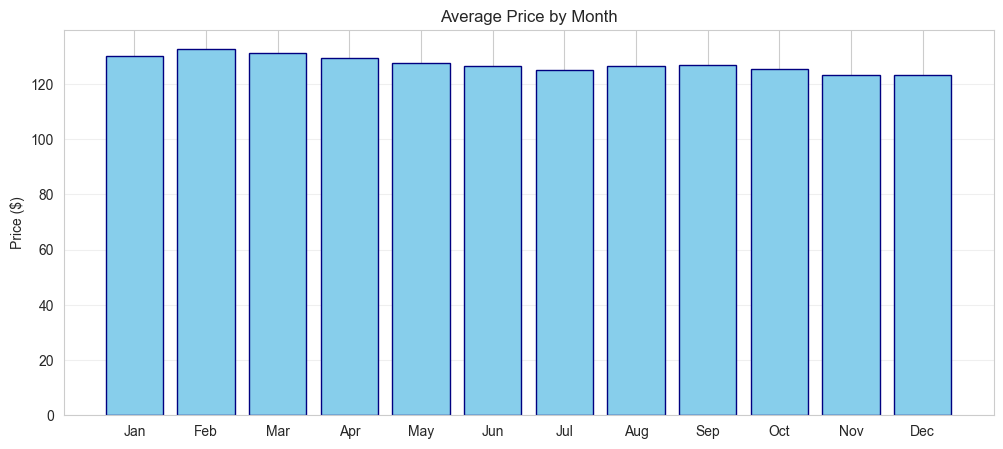


Average Price by Month:
Jan: $130.33
Feb: $132.86
Mar: $131.20
Apr: $129.50
May: $127.74
Jun: $126.42
Jul: $125.07
Aug: $126.45
Sep: $126.92
Oct: $125.37
Nov: $123.13
Dec: $123.42


In [51]:
# Monthly analysis
data["Month"] = data.index.month
monthly_avg = data.groupby("Month")["Close"].mean()

months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, 13), monthly_avg.values, color="skyblue", edgecolor="navy")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("Average Price by Month")
ax.set_ylabel("Price ($)")
ax.grid(True, alpha=0.3, axis="y")
plt.show()

print("\nAverage Price by Month:")
for i, month in enumerate(months):
    print(f"{month}: ${monthly_avg.iloc[i]:.2f}")

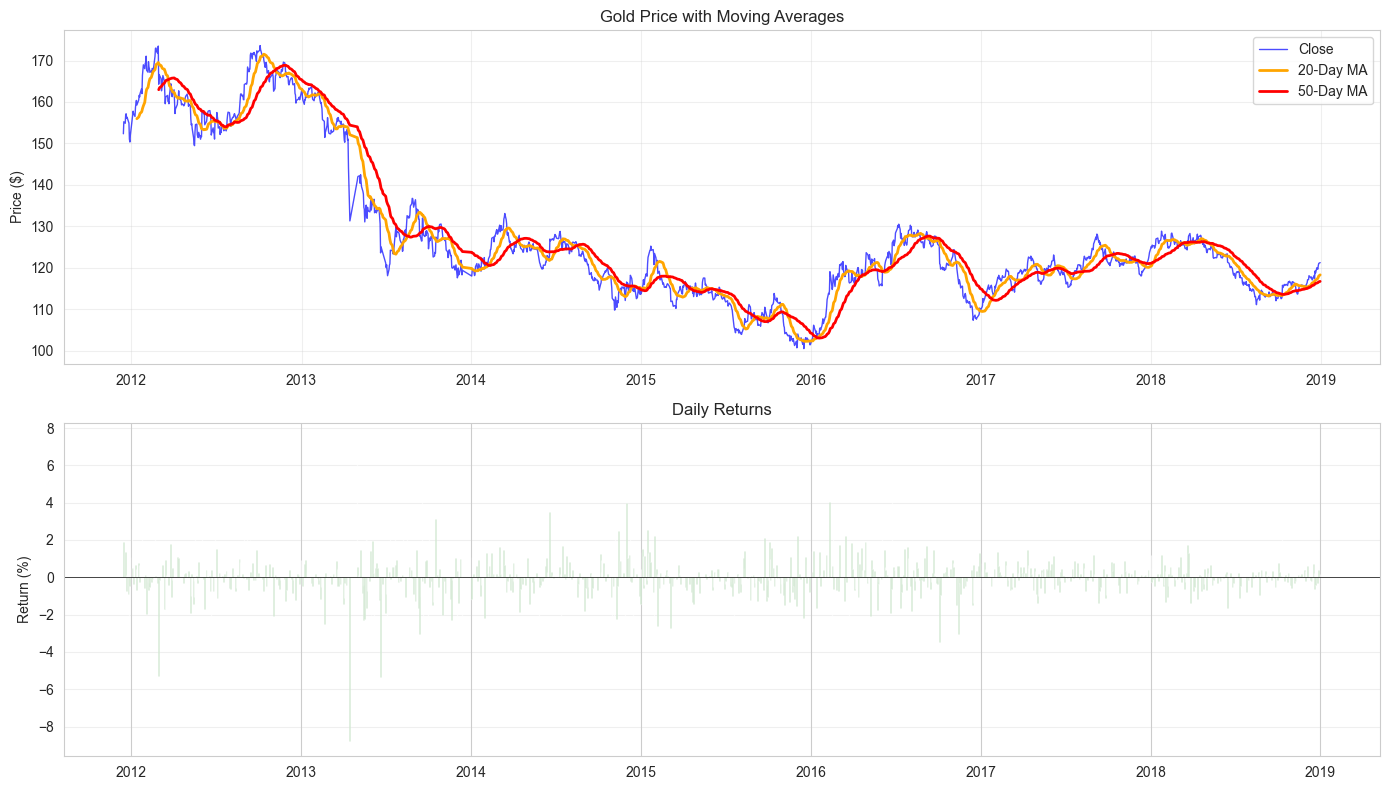

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Calculate moving averages
MA20 = data["Close"].rolling(20).mean()
MA50 = data["Close"].rolling(50).mean()
daily_return = data["Close"].pct_change() * 100

# Plot 1: Price with Moving Averages
axes[0].plot(
    data.index, data["Close"], label="Close", color="blue", linewidth=1, alpha=0.7
)
axes[0].plot(data.index, MA20, label="20-Day MA", color="orange", linewidth=2)
axes[0].plot(data.index, MA50, label="50-Day MA", color="red", linewidth=2)
axes[0].set_title("Gold Price with Moving Averages")
axes[0].set_ylabel("Price ($)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Daily Returns
axes[1].bar(data.index, daily_return, color="green", alpha=0.6)
axes[1].set_title("Daily Returns")
axes[1].set_ylabel("Return (%)")
axes[1].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [53]:
# Calculate moving averages
data["MA20"] = data["Close"].rolling(20).mean()
data["MA50"] = data["Close"].rolling(50).mean()

# Calculate daily returns
data["Return"] = data["Close"].pct_change() * 100

print("\nMoving Averages (Latest):")
print(f"Close: ${data['Close'].iloc[-1]:.2f}")
print(f"20-Day MA: ${data['MA20'].iloc[-1]:.2f}")
print(f"50-Day MA: ${data['MA50'].iloc[-1]:.2f}")
print(f"\nDaily Returns:")
print(f"Average: {data['Return'].mean():.3f}%")
print(f"Best Day: {data['Return'].max():.2f}%")
print(f"Worst Day: {data['Return'].min():.2f}%")


Moving Averages (Latest):
Close: $121.25
20-Day MA: $118.29
50-Day MA: $116.72

Daily Returns:
Average: -0.009%
Best Day: 7.46%
Worst Day: -8.78%


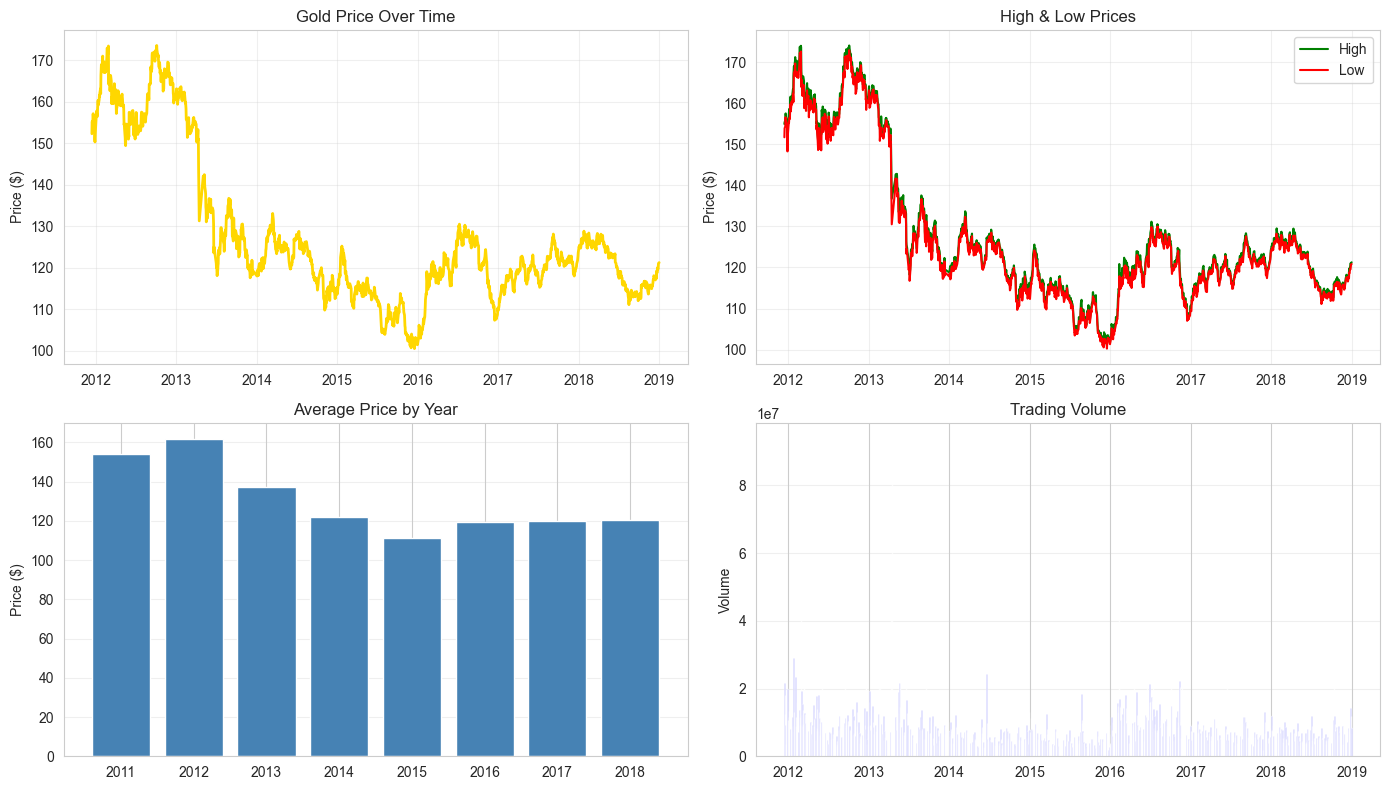

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot 1: Price over time
axes[0, 0].plot(data.index, data["Close"], color="gold", linewidth=2)
axes[0, 0].set_title("Gold Price Over Time")
axes[0, 0].set_ylabel("Price ($)")
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: High and Low
axes[0, 1].plot(data.index, data["High"], label="High", color="green")
axes[0, 1].plot(data.index, data["Low"], label="Low", color="red")
axes[0, 1].set_title("High & Low Prices")
axes[0, 1].set_ylabel("Price ($)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Yearly average
axes[1, 0].bar(yearly_avg.index, yearly_avg.values, color="steelblue")
axes[1, 0].set_title("Average Price by Year")
axes[1, 0].set_ylabel("Price ($)")
axes[1, 0].grid(True, alpha=0.3, axis="y")

# Plot 4: Volume
axes[1, 1].bar(data.index, data["Volume"], color="blue", alpha=0.7)
axes[1, 1].set_title("Trading Volume")
axes[1, 1].set_ylabel("Volume")
axes[1, 1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [55]:
# Extract year and month
data["Year"] = data.index.year

# Yearly average
yearly_avg = data.groupby("Year")["Close"].mean()
print("\nAverage Price by Year:")
print(yearly_avg.round(2))


Average Price by Year:
Year
2011    154.29
2012    161.87
2013    137.43
2014    121.83
2015    111.11
2016    119.38
2017    119.72
2018    120.21
Name: Close, dtype: float64


In [56]:
print("\nGold Price Summary:")
print(f"Average: ${data['Close'].mean():.2f}")
print(f"Min: ${data['Close'].min():.2f}")
print(f"Max: ${data['Close'].max():.2f}")
print(f"Latest: ${data['Close'].iloc[-1]:.2f}")


Gold Price Summary:
Average: $127.32
Min: $100.50
Max: $173.61
Latest: $121.25


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv(r"C:\Users\admin\Desktop\Sem lab\TSA\FINAL_USO.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")
data.set_index("Date", inplace=True)

print(f"Data from {data.index.min().date()} to {data.index.max().date()}")
print(f"Total records: {len(data)}")

Data from 2011-12-15 to 2018-12-31
Total records: 1718
